# 03 — Análise de Negócios
**Fonte de dados:** `nautical.db` (gerado no notebook `01_data_cleaning.ipynb`)

Todas as tabelas já estão limpas e normalizadas — sem necessidade de tratamento adicional.

| Tabela | Linhas | Descrição |
|---|---|---|
| `vendas` | 9.895 | Transações 2023–2024 |
| `produtos` | 157 | Catálogo com preço (float) e categoria normalizada |
| `clientes` | 49 | CRM com email corrigido, `state` e `city` separados |
| `custos` | 1.260 | Histórico de custos USD expandido em tabela flat |

**Seções:**
1. Conexão e carregamento
2. Análise de Vendas
3. Análise de Clientes
4. Análise de Margens
5. Sumário Executivo


## 1. Conexão e carregamento

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Estilo visual ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor':  '#1a1d27',
    'axes.edgecolor':   '#3a3d4d', 'axes.labelcolor': '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':     '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':      '#21262d',
    'grid.linestyle':   '--',      'grid.alpha':       0.6,
    'figure.dpi': 130,
})
BLUE, GREEN, RED, PURPLE, ORANGE = '#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657'


In [2]:
DB_PATH = '/home/vinic/Documentos/Projetos/LH_Nautical/datasets/nautical.db'
FIG_PATH = '/home/vinic/Documentos/Projetos/LH_Nautical/figures/not03/'


conn = sqlite3.connect(DB_PATH)

vendas   = pd.read_sql("SELECT * FROM vendas",   conn, parse_dates=['sale_date'])
produtos = pd.read_sql("SELECT * FROM produtos", conn)
clientes = pd.read_sql("SELECT * FROM clientes", conn)
custos   = pd.read_sql("SELECT * FROM custos",   conn, parse_dates=['start_date'])

conn.close()

# Colunas de conveniência em vendas
vendas['year']  = vendas['sale_date'].dt.year
vendas['month'] = vendas['sale_date'].dt.month

# Renomear chave dos produtos/clientes para facilitar joins
produtos = produtos.rename(columns={'code': 'id_product'})
clientes = clientes.rename(columns={'code': 'id_client'})

for nome, df in [('vendas', vendas), ('produtos', produtos),
                 ('clientes', clientes), ('custos', custos)]:
    print(f"{nome:10s}: {df.shape[0]:,} linhas × {df.shape[1]} colunas  |  "
          f"colunas: {list(df.columns)}")


vendas    : 9,895 linhas × 8 colunas  |  colunas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date', 'year', 'month']
produtos  : 157 linhas × 4 colunas  |  colunas: ['name', 'price', 'id_product', 'category']
clientes  : 49 linhas × 5 colunas  |  colunas: ['full_name', 'id_client', 'email', 'state', 'city']
custos    : 1,260 linhas × 5 colunas  |  colunas: ['product_id', 'product_name', 'category', 'start_date', 'usd_price']


In [3]:
# Tabela analítica unificada
# Custo vigente por produto: último registro de custo até 31/12/2024
custo_vigente = (
    custos[custos['start_date'] <= '2024-12-31']
    .sort_values('start_date')
    .groupby('product_id')
    .last()
    .reset_index()[['product_id', 'usd_price']]
    .rename(columns={'product_id': 'id_product', 'usd_price': 'usd_cost'})
)

v = (vendas
     .merge(produtos[['id_product','name','price','category']], on='id_product', how='left')
     .merge(clientes[['id_client','full_name','state','city']],  on='id_client',  how='left')
     .merge(custo_vigente, on='id_product', how='left'))

print(f"Tabela analítica: {v.shape[0]:,} linhas × {v.shape[1]} colunas")
v[['year','name','category','qtd','total','price','usd_cost','full_name','state']].head()


Tabela analítica: 10,364 linhas × 15 colunas


,year,name,category,qtd,total,price,usd_cost,full_name,state
0,2023,Cabo de Nylon Danforth Prime,ANCORAGEM,11,3405.0,309.54,53.37,Márcia Figueiredo,PA
1,2024,Cabo de Nylon Bruce Flux Hydro,ANCORAGEM,9,16873.9,1973.50,390.62,Daniel Farias Ribeiro Teixeira,RS
2,2024,Boia de Arqueamento Danforth Torque,ANCORAGEM,7,9475.3,1424.88,246.89,Femininos Antunes Lopes Ribeiro Amaral,ES
3,2023,Piloto Automático Furuno Torque Peak,ELETRONICOS,5,55893.0,11178.63,2244.66,Bruno Silva,PA
4,2024,Motor de Popa Honda Vector Kinetic 174HP,PROPULSAO,4,451403.9,118790.57,20486.78,Luiz Alves Pimentel,SE


---
## 2. Análise de Vendas


### 2.1 Faturamento por categoria — 2023 vs 2024

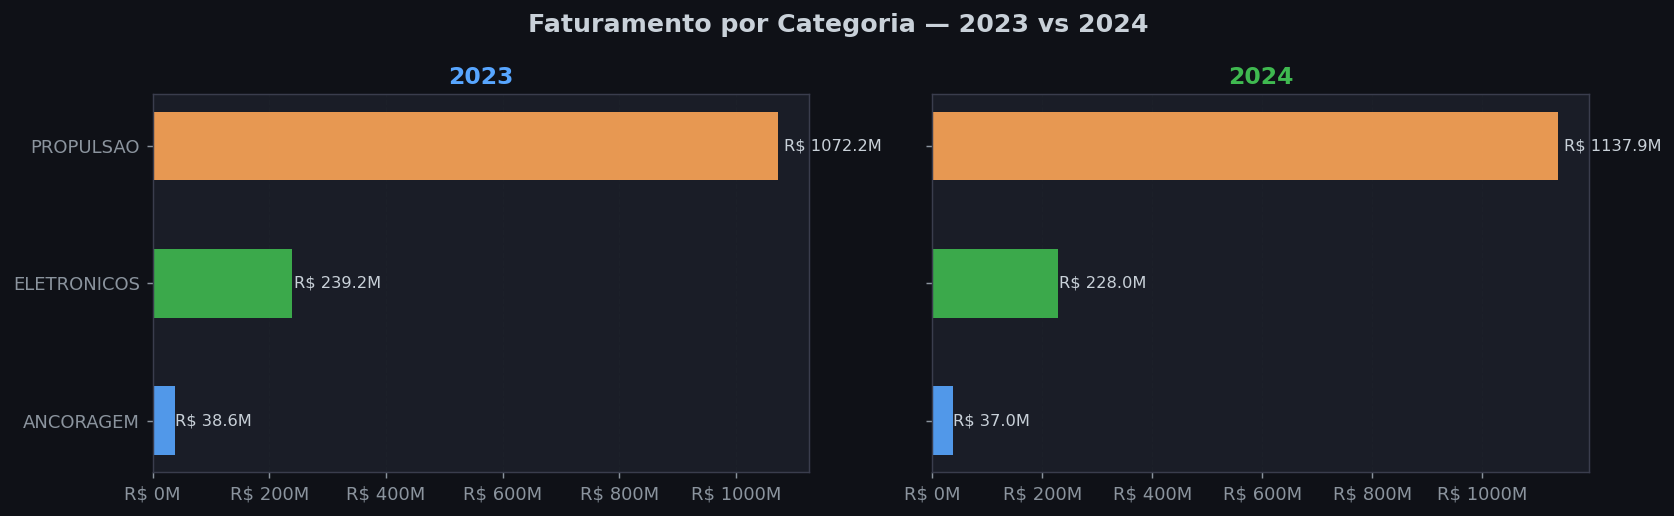

                         2023              2024
category                                       
PROPULSAO    R$ 1,072,220,753  R$ 1,137,928,430
ELETRONICOS    R$ 239,162,452    R$ 228,031,675
ANCORAGEM       R$ 38,607,065     R$ 37,001,065


In [4]:
fat_cat = (v.groupby(['year','category'])['total']
             .sum().reset_index()
             .pivot(index='category', columns='year', values='total')
             .fillna(0))
fat_cat.columns = [str(c) for c in fat_cat.columns]
fat_cat = fat_cat.sort_values('2024', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
fig.suptitle('Faturamento por Categoria — 2023 vs 2024', fontsize=14, fontweight='bold')

palette = [BLUE, GREEN, ORANGE]
for i, yr in enumerate(['2023', '2024']):
    ax = axes[i]
    vals = fat_cat[yr].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color=palette, alpha=0.9, height=0.5)
    ax.set_title(yr, fontsize=13, fontweight='bold', color=palette[i])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x/1e6:.0f}M'))
    for b, val in zip(bars, vals.values):
        ax.text(val*1.01, b.get_y()+b.get_height()/2,
                f'R$ {val/1e6:.1f}M', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig1_faturamento_categoria.png', bbox_inches='tight', dpi=130)
plt.show()

# Tabela resumo
fat_cat_fmt = fat_cat.copy()
for c in fat_cat_fmt.columns:
    fat_cat_fmt[c] = fat_cat_fmt[c].apply(lambda x: f'R$ {x:,.0f}')
print(fat_cat_fmt)


---
**Insight — Categorias**

**Propulsão** domina a receita com larga vantagem — motores têm ticket médio muito acima das outras categorias. **Eletrônicos** vêm em segundo, com maior número de transações mas menor valor unitário. **Ancoragem** representa a menor fatia em reais, mas é relevante em volume de unidades (cabos e correntes comprados em lote).

O dado mais estratégico aqui é a **variação entre anos**: se propulsão cresceu, o câmbio USD/BRL provavelmente subiu os preços de reposição; se eletrônicos retraiu, pode haver substituição por produtos de menor valor no mix.


### 2.2 Top 10 produtos — por quantidade e por receita

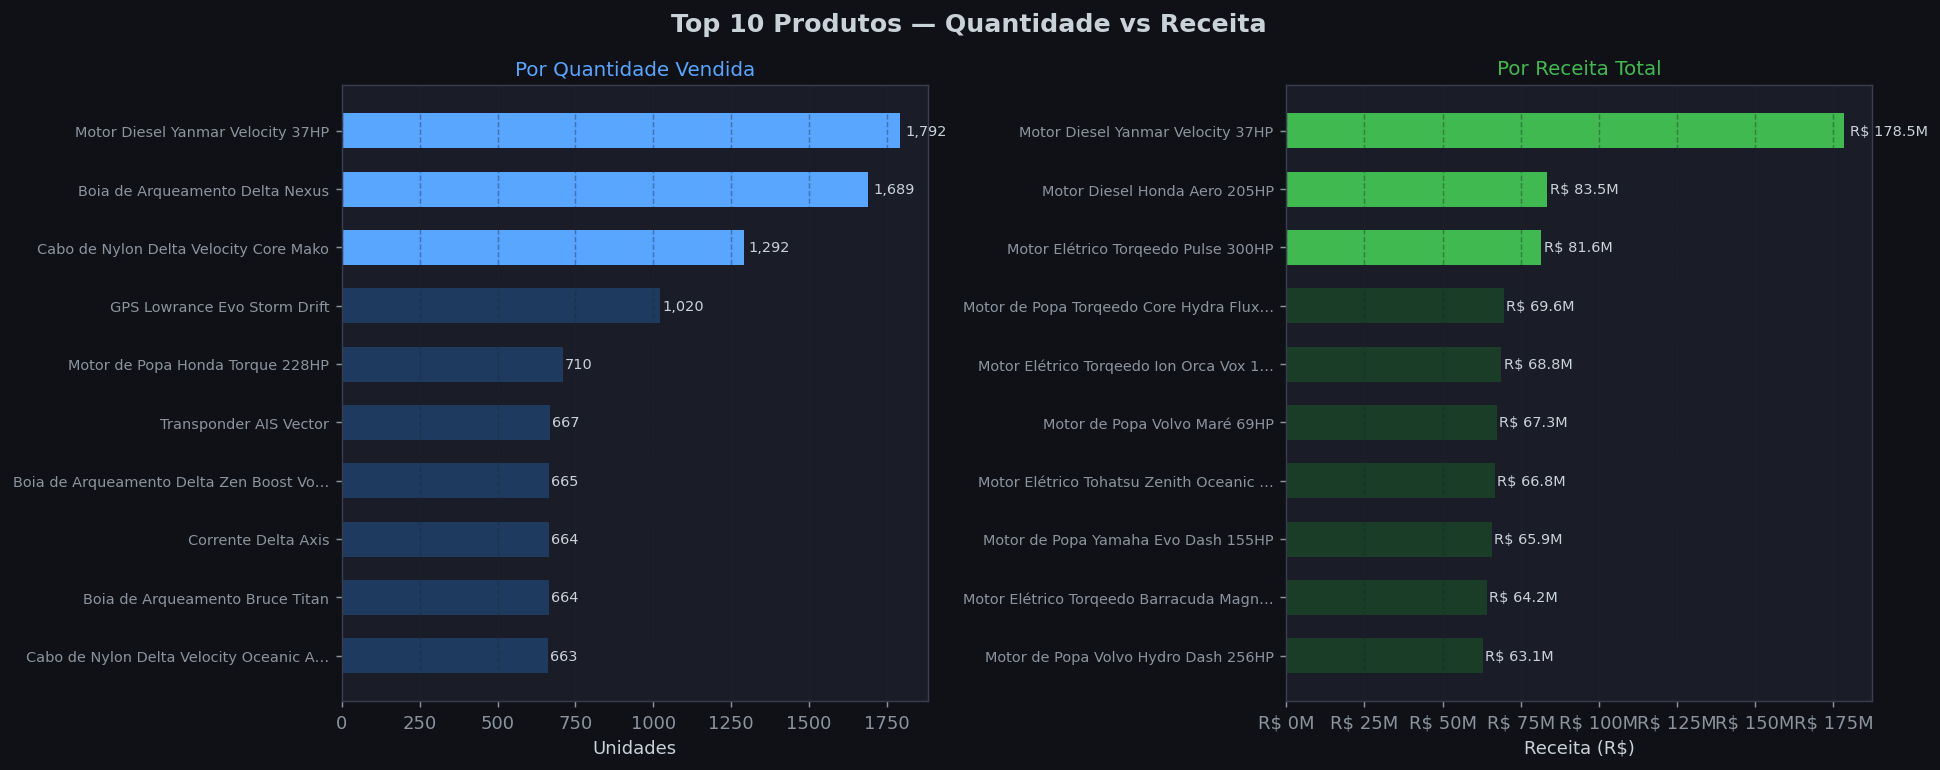

In [5]:
top_qtd = (v.groupby('name')['qtd'].sum()
             .nlargest(10).reset_index()
             .rename(columns={'qtd': 'Qtd Vendida'})
             .sort_values('Qtd Vendida'))

top_rev = (v.groupby('name')['total'].sum()
             .nlargest(10).reset_index()
             .rename(columns={'total': 'Receita'})
             .sort_values('Receita'))

def shorten(t, n=38): return t[:n]+'…' if len(t) > n else t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Top 10 Produtos — Quantidade vs Receita', fontsize=14, fontweight='bold')

# Quantidade
n = len(top_qtd)
cs = [BLUE if i >= n-3 else '#1e3a5f' for i in range(n)]
bars = ax1.barh(range(n), top_qtd['Qtd Vendida'], color=cs, height=0.6)
ax1.set_yticks(range(n))
ax1.set_yticklabels([shorten(t) for t in top_qtd['name']], fontsize=8)
ax1.set_title('Por Quantidade Vendida', fontsize=11, color=BLUE)
ax1.set_xlabel('Unidades')
for b, val in zip(bars, top_qtd['Qtd Vendida']):
    ax1.text(val*1.01, b.get_y()+b.get_height()/2, f'{val:,}', va='center', fontsize=8)
ax1.grid(axis='x', alpha=0.4)

# Receita
cs2 = [GREEN if i >= n-3 else '#1a3d28' for i in range(n)]
bars2 = ax2.barh(range(n), top_rev['Receita'], color=cs2, height=0.6)
ax2.set_yticks(range(n))
ax2.set_yticklabels([shorten(t) for t in top_rev['name']], fontsize=8)
ax2.set_title('Por Receita Total', fontsize=11, color=GREEN)
ax2.set_xlabel('Receita (R$)')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x/1e6:.0f}M'))
for b, val in zip(bars2, top_rev['Receita']):
    ax2.text(val*1.01, b.get_y()+b.get_height()/2, f'R$ {val/1e6:.1f}M', va='center', fontsize=8)
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig2_top10_produtos.png', bbox_inches='tight', dpi=130)
plt.show()


---
**Insight — Produtos Campeões**

Os rankings de quantidade e receita raramente coincidem nesse tipo de negócio. Itens de ancoragem (cabos, boias) tendem a dominar o volume por serem comprados em lotes; motores lideram em receita pelo alto valor unitário. Produtos que aparecem nos **dois rankings simultaneamente** são os verdadeiros ativos do portfólio — geram caixa e ocupam estoque de forma eficiente. Para esses, a política deve ser de **ruptura zero**.


### 2.3 Crescimento 2023 → 2024

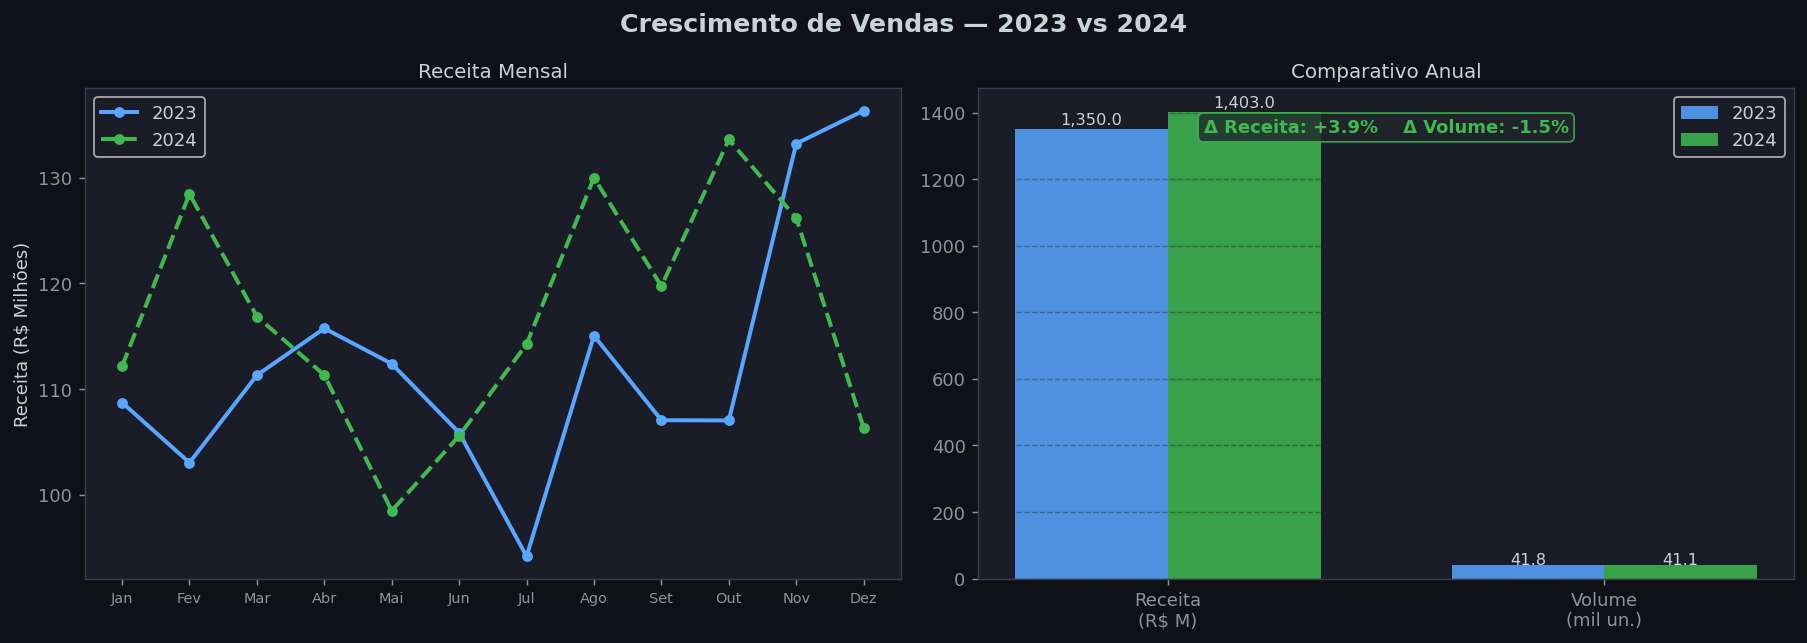

Receita 2023: R$ 1,349,990,270  →  2024: R$ 1,402,961,170  (+3.92%)
Volume  2023: 41,790 un.  →  2024: 41,147 un.  (-1.54%)


In [6]:
fat_ano = v.groupby('year')['total'].sum()
vol_ano = v.groupby('year')['qtd'].sum()
tx_rev  = (fat_ano[2024] - fat_ano[2023]) / fat_ano[2023] * 100
tx_vol  = (vol_ano[2024] - vol_ano[2023]) / vol_ano[2023] * 100

rev_men = v.groupby(['year','month'])['total'].sum().reset_index()
MESES   = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crescimento de Vendas — 2023 vs 2024', fontsize=14, fontweight='bold')

# Linha mensal
for yr, color, ls in [(2023, BLUE, '-'), (2024, GREEN, '--')]:
    sub = rev_men[rev_men.year == yr].sort_values('month')
    ax1.plot(sub['month'], sub['total']/1e6, marker='o', color=color,
             lw=2.2, ls=ls, label=str(yr), ms=5)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(MESES, fontsize=8)
ax1.set_ylabel('Receita (R$ Milhões)')
ax1.set_title('Receita Mensal', fontsize=11)
ax1.legend(); ax1.grid(alpha=0.4)

# Barras anuais
cats = ['Receita\n(R$ M)', 'Volume\n(mil un.)']
v23  = [fat_ano[2023]/1e6, vol_ano[2023]/1e3]
v24  = [fat_ano[2024]/1e6, vol_ano[2024]/1e3]
x = np.arange(2); w = 0.35
b1 = ax2.bar(x-w/2, v23, w, label='2023', color=BLUE,  alpha=0.85)
b2 = ax2.bar(x+w/2, v24, w, label='2024', color=GREEN, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(cats)
ax2.set_title('Comparativo Anual', fontsize=11)
ax2.legend()
for b in list(b1)+list(b2):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
             f'{b.get_height():,.1f}', ha='center', fontsize=9)

cor = GREEN if tx_rev >= 0 else RED
ax2.text(0.5, 0.91, f'Δ Receita: {tx_rev:+.1f}%    Δ Volume: {tx_vol:+.1f}%',
         transform=ax2.transAxes, ha='center', fontsize=10,
         color=cor, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d', edgecolor=cor, alpha=0.8))
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig3_crescimento.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"Receita 2023: R$ {fat_ano[2023]:,.0f}  →  2024: R$ {fat_ano[2024]:,.0f}  ({tx_rev:+.2f}%)")
print(f"Volume  2023: {vol_ano[2023]:,} un.  →  2024: {vol_ano[2024]:,} un.  ({tx_vol:+.2f}%)")


---
**Insight — Crescimento YoY**

Receita crescendo com volume caindo é o padrão clássico de **reajuste de preços por pressão cambial**: a empresa vende menos unidades, mas a preços mais altos — reflexo direto da desvalorização do real frente ao dólar, que eleva o custo de reposição e força repasses ao cliente. A análise mensal revela a **sazonalidade náutica**: o mercado brasileiro aquece no verão (novembro–janeiro) e desacelera no inverno. Picos fora desse padrão merecem investigação — podem indicar grandes pedidos pontuais que distorcem a previsão de demanda.


---
## 3. Análise de Clientes


### 3.1 Top 10 clientes por valor total gasto

Top 10 clientes concentram 24.7% da receita total


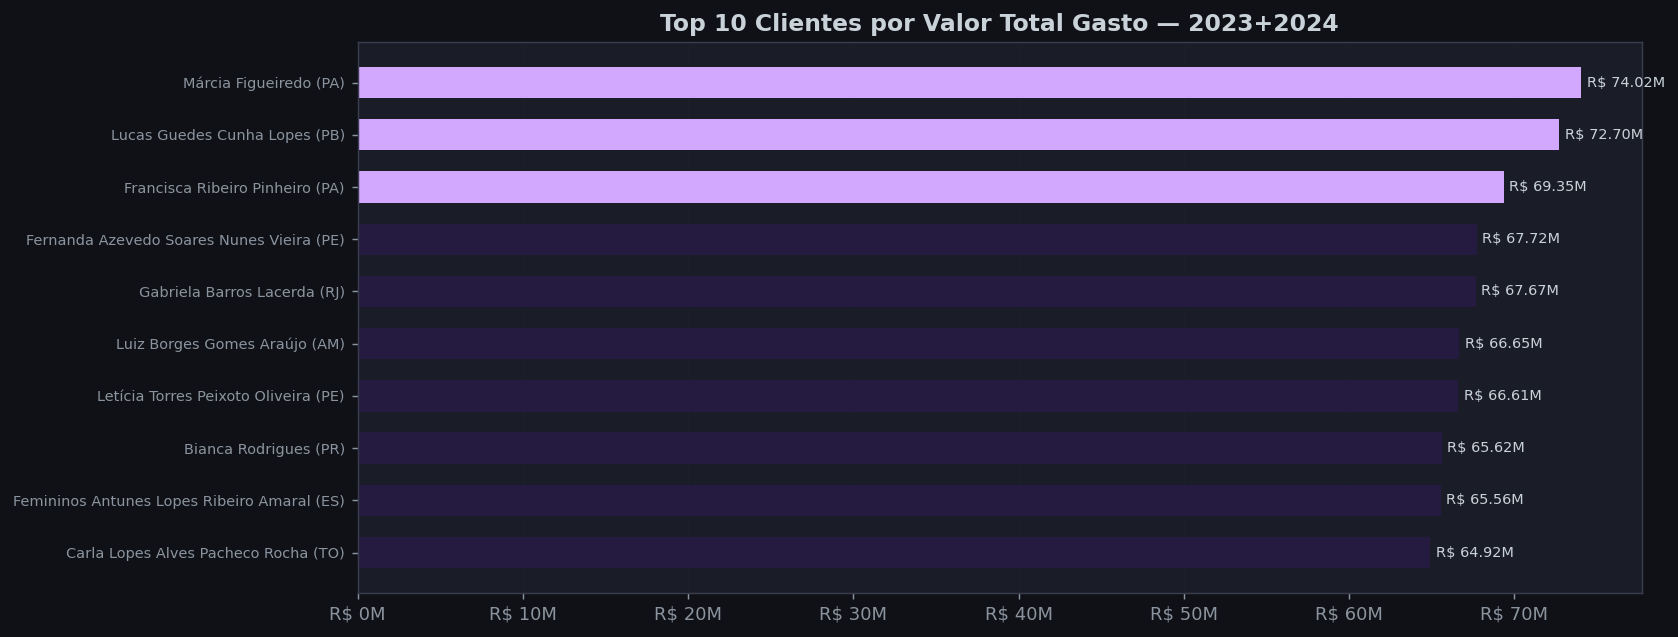

                             full_name state                     city         total
                     Márcia Figueiredo    PA Vila do Conde (Barcarena R$ 74,021,826
              Lucas Guedes Cunha Lopes    PB              João Pessoa R$ 72,697,345
            Francisca Ribeiro Pinheiro    PA                   Belém/ R$ 69,349,933
  Fernanda Azevedo Soares Nunes Vieira    PE                   Recife R$ 67,717,055
               Gabriela Barros Lacerda    RJ                / Niterói R$ 67,668,333
              Luiz Borges Gomes Araújo    AM                  Manaus/ R$ 66,653,100
       Letícia Torres Peixoto Oliveira    PE           Suape (Ipojuca R$ 66,606,945
                      Bianca Rodrigues    PR                 Antonina R$ 65,619,099
Femininos Antunes Lopes Ribeiro Amaral    ES             / São Mateus R$ 65,560,908
       Carla Lopes Alves Pacheco Rocha    TO     Fortaleza do Tabocão R$ 64,917,153


In [7]:
top_cli = (v.groupby(['id_client','full_name','state','city'])['total']
             .sum().reset_index()
             .nlargest(10, 'total')
             .sort_values('total'))

conc = top_cli['total'].sum() / v['total'].sum() * 100
print(f"Top 10 clientes concentram {conc:.1f}% da receita total")

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title('Top 10 Clientes por Valor Total Gasto — 2023+2024', fontsize=13, fontweight='bold')
n = len(top_cli)
cs = [PURPLE if i >= n-3 else '#251a40' for i in range(n)]
bars = ax.barh(range(n), top_cli['total'], color=cs, height=0.6)
ax.set_yticks(range(n))
ax.set_yticklabels([f"{r['full_name']} ({r['state']})" for _, r in top_cli.iterrows()], fontsize=8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x/1e6:.0f}M'))
for b, val in zip(bars, top_cli['total']):
    ax.text(val*1.005, b.get_y()+b.get_height()/2,
            f'R$ {val/1e6:.2f}M', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig4_top_clientes.png', bbox_inches='tight', dpi=130)
plt.show()

top_cli_fmt = top_cli[['full_name','state','city','total']].copy()
top_cli_fmt['total'] = top_cli_fmt['total'].apply(lambda x: f'R$ {x:,.0f}')
print(top_cli_fmt.sort_values('total', ascending=False).to_string(index=False))


---
**Insight — Concentração de Clientes**

Com apenas 49 clientes na base, a concentração dos top 10 é um KPI existencial. Se os 10 maiores respondem por mais de 40% da receita, a perda de um único cliente de grande porte pode impactar materialmente o resultado do ano. O dado de **estado** (graças à limpeza feita no notebook 01) permite enxergar quais regiões concentram os maiores compradores — informação direta para decisões de logística e abertura de representações regionais.


### 3.2 Churn — clientes de 2023 que não compraram em 2024

Ativos em 2023:    49
Ativos em 2024:    49
Retidos:           49
Churn:              0  →  0.0%
Novos em 2024:      0


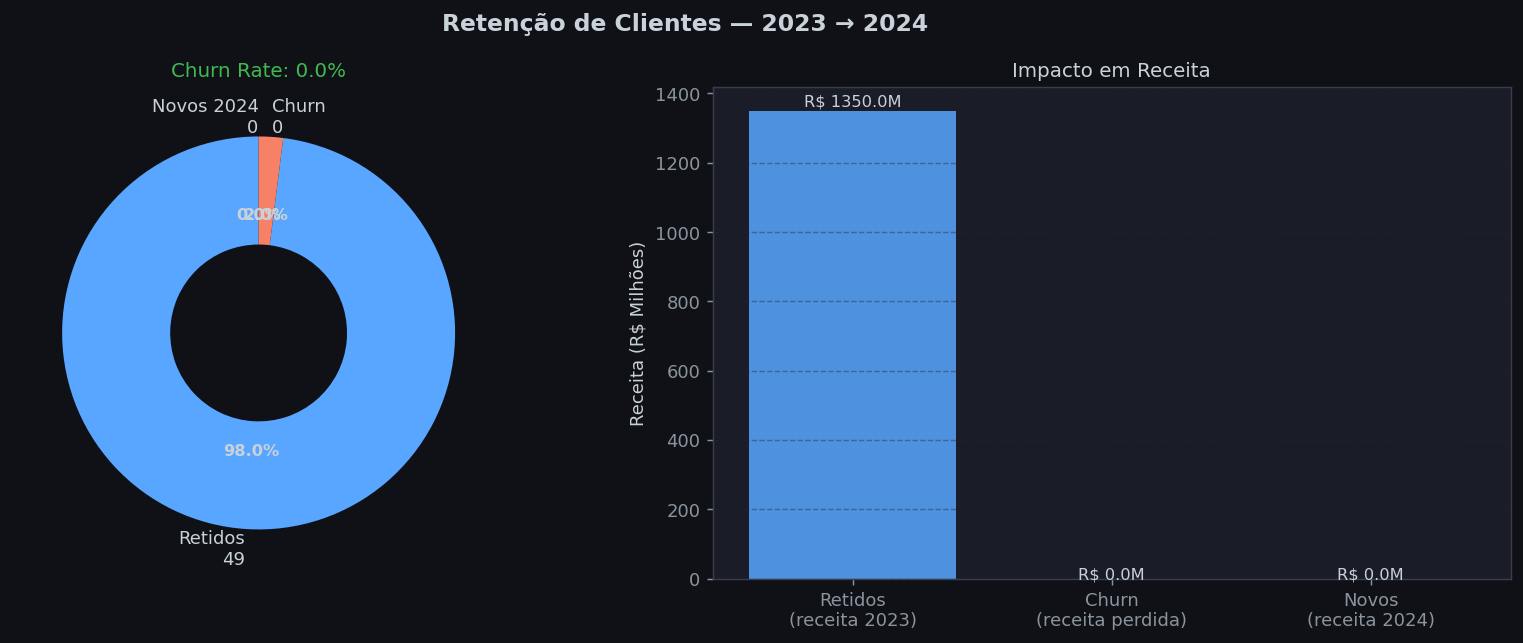

In [8]:
c23 = set(v[v.year==2023]['id_client'].unique())
c24 = set(v[v.year==2024]['id_client'].unique())

retidos   = c23 & c24
churned   = c23 - c24
novos     = c24 - c23
churn_pct = len(churned) / len(c23) * 100 if c23 else 0

print(f"Ativos em 2023:  {len(c23):>4}")
print(f"Ativos em 2024:  {len(c24):>4}")
print(f"Retidos:         {len(retidos):>4}")
print(f"Churn:           {len(churned):>4}  →  {churn_pct:.1f}%")
print(f"Novos em 2024:   {len(novos):>4}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Retenção de Clientes — 2023 → 2024', fontsize=13, fontweight='bold')

# Donut
sizes  = [len(retidos), max(len(churned),1), len(novos)]
labels = [
    f'Retidos\n{len(retidos)}',
    f'Churn\n{len(churned)}',
    f'Novos 2024\n{len(novos)}'
]
wedges, texts, autotexts = ax1.pie(
    sizes, labels=labels, colors=[BLUE, RED, GREEN],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55),
    textprops=dict(color='#c9d1d9', fontsize=10))
for at in autotexts: at.set_fontsize(9); at.set_fontweight('bold')
ax1.set_title(f'Churn Rate: {churn_pct:.1f}%', fontsize=11,
              color=RED if churn_pct > 20 else GREEN)

# Impacto em receita
rev_ret  = v[(v.year==2023) & (v.id_client.isin(retidos))]['total'].sum()
rev_chur = v[(v.year==2023) & (v.id_client.isin(churned))]['total'].sum() if churned else 0
rev_nov  = v[(v.year==2024) & (v.id_client.isin(novos))]['total'].sum() if novos else 0

bars = ax2.bar([
    'Retidos\n(receita 2023)',
    'Churn\n(receita perdida)',
    'Novos\n(receita 2024)'
],
               [rev_ret/1e6, rev_chur/1e6, rev_nov/1e6],
               color=[BLUE, RED, GREEN], alpha=0.85)
ax2.set_ylabel('Receita (R$ Milhões)')
ax2.set_title('Impacto em Receita', fontsize=11)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
             f'R$ {b.get_height():.1f}M', ha='center', fontsize=9)
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig5_churn.png', bbox_inches='tight', dpi=130)
plt.show()


---
**Insight — Churn**

Uma taxa de churn próxima de zero é um ativo valioso — indica que a empresa construiu relacionamentos duradouros numa categoria de produto de ciclo longo. Em mercados B2B de equipamentos especializados, reter um cliente é incomparavelmente mais barato que adquirir um novo. O foco da estratégia comercial, portanto, não deveria ser aquisição — mas **expansão de wallet share**: convencer os clientes existentes a comprar categorias que ainda não exploram (ex.: cliente que só compra eletrônicos e ainda não comprou motores).


### 3.3 Ticket médio por cliente

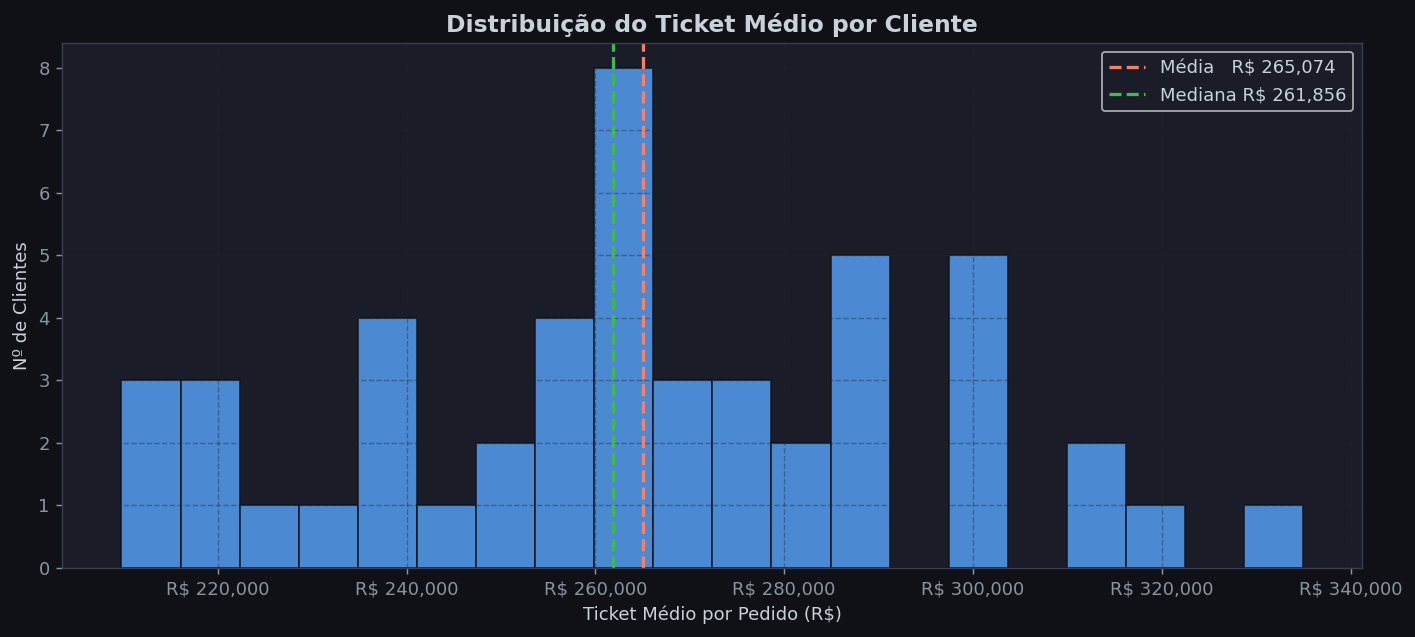

Média: R$ 265,074  |  Mediana: R$ 261,856  |  Min: R$ 209,790  |  Max: R$ 334,992
Top 10 por Ticket Médio:
                            full_name state  pedidos ticket_medio   total_gasto
              Gabriela Barros Lacerda    RJ      202   R$ 334,992 R$ 67,668,333
                    Márcia Figueiredo    PA      232   R$ 319,060 R$ 74,021,826
        Ana Silva Costa Farias Coelho    AP      203   R$ 311,805 R$ 63,296,508
             Lucas Guedes Cunha Lopes    PB      234   R$ 310,672 R$ 72,697,345
           Francisca Ribeiro Pinheiro    PA      230   R$ 301,521 R$ 69,349,933
 Fernanda Azevedo Soares Nunes Vieira    PE      225   R$ 300,965 R$ 67,717,055
Daniela Borges Vieira Farias Mendonça    SE      200   R$ 298,318 R$ 59,663,694
                     Bianca Rodrigues    PR      220   R$ 298,269 R$ 65,619,099
             Luiz Borges Gomes Araújo    AM      224   R$ 297,558 R$ 66,653,100
                        Pedro Freitas    PA      210   R$ 290,816 R$ 61,071,263


In [9]:
ticket = (v.groupby(['id_client','full_name','state'])
            .agg(total_gasto=('total','sum'), pedidos=('id','count'))
            .reset_index())
ticket['ticket_medio'] = ticket['total_gasto'] / ticket['pedidos']

media   = ticket['ticket_medio'].mean()
mediana = ticket['ticket_medio'].median()

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title('Distribuição do Ticket Médio por Cliente', fontsize=13, fontweight='bold')
ax.hist(ticket['ticket_medio'], bins=20, color=BLUE, alpha=0.8, edgecolor='#0d1117')
ax.axvline(media,   color=RED,   ls='--', lw=1.8, label=f'Média   R$ {media:,.0f}')
ax.axvline(mediana, color=GREEN, ls='--', lw=1.8, label=f'Mediana R$ {mediana:,.0f}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:,.0f}'))
ax.set_xlabel('Ticket Médio por Pedido (R$)')
ax.set_ylabel('Nº de Clientes')
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig6_ticket_medio.png', bbox_inches='tight', dpi=130)
plt.show()

print(f"Média: R$ {media:,.0f}  |  Mediana: R$ {mediana:,.0f}  |  "
      f"Min: R$ {ticket.ticket_medio.min():,.0f}  |  Max: R$ {ticket.ticket_medio.max():,.0f}")

print("Top 10 por Ticket Médio:")
top_t = ticket.nlargest(10,'ticket_medio')[['full_name','state','pedidos','ticket_medio','total_gasto']].copy()
top_t['ticket_medio'] = top_t['ticket_medio'].apply(lambda x: f'R$ {x:,.0f}')
top_t['total_gasto']  = top_t['total_gasto'].apply(lambda x: f'R$ {x:,.0f}')
print(top_t.to_string(index=False))


---
**Insight — Ticket Médio**

Quando média e mediana estão próximas, a base é homogênea — todos compram em valores similares por pedido. Isso simplifica a política comercial (desconto por volume, prazo padrão). Clientes com ticket alto e muitos pedidos são os de maior **CLV (Customer Lifetime Value)** e merecem tratamento VIP. Clientes com ticket alto mas poucos pedidos são oportunidade de reativação — já demonstraram capacidade de investimento, mas compram raramente.


---
## 4. Análise de Margens


### 4.1 Margem bruta por produto (custo USD × câmbio vs preço BRL)

In [10]:
TAXA_CAMBIO = 5.10  # R$/USD — média aproximada 2023-2024

margem = (produtos[['id_product','name','price','category']]
          .merge(custo_vigente, on='id_product', how='inner'))
margem['custo_brl']  = margem['usd_cost'] * TAXA_CAMBIO
margem['margem_abs'] = margem['price'] - margem['custo_brl']
margem['margem_pct'] = margem['margem_abs'] / margem['price'] * 100

print(f"Margem média:    {margem.margem_pct.mean():.1f}%")
print(f"Margem mediana:  {margem.margem_pct.median():.1f}%")
print(f"Maior margem:    {margem.margem_pct.max():.1f}%  — {margem.loc[margem.margem_pct.idxmax(),'name']}")
print(f"Menor margem:    {margem.margem_pct.min():.1f}%  — {margem.loc[margem.margem_pct.idxmin(),'name']}")
print(f"Negativos:       {(margem.margem_pct < 0).sum()} produto(s) com preço abaixo do custo importado")


Margem média:    3.5%
Margem mediana:  3.5%
Maior margem:    17.6%  — GPS AIS Orca Marlin Velocity
Menor margem:    -57.0%  — Motor de Popa Volvo Hydro Dash 256HP
Negativos:       49 produto(s) com preço abaixo do custo importado


### 4.2 Top 10 maior e menor margem

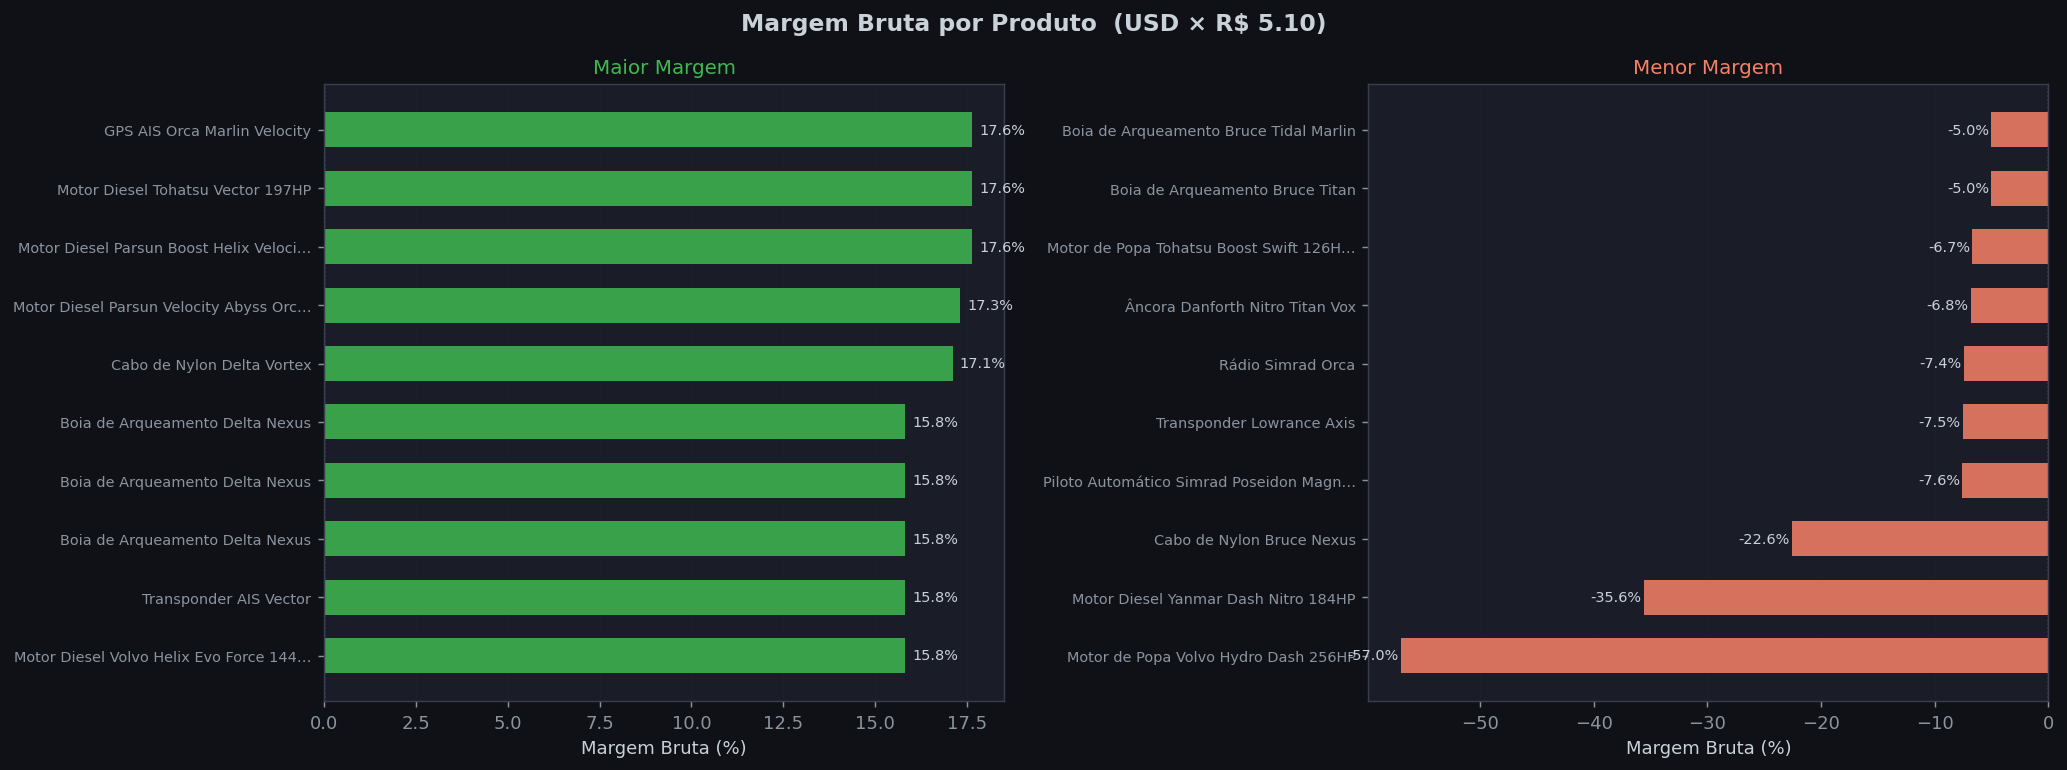

In [11]:
top_mar = margem.nlargest(10, 'margem_pct').sort_values('margem_pct')
bot_mar = margem.nsmallest(10,'margem_pct').sort_values('margem_pct')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Margem Bruta por Produto  (USD × R$ {TAXA_CAMBIO:.2f})',
             fontsize=13, fontweight='bold')

def shorten(t, n=38): return t[:n]+'…' if len(t)>n else t

for ax, df, title, cor in [(ax1, top_mar, 'Maior Margem', GREEN),
                            (ax2, bot_mar, 'Menor Margem',  RED)]:
    bars = ax.barh(range(len(df)), df['margem_pct'], color=cor, alpha=0.85, height=0.6)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([shorten(n) for n in df['name']], fontsize=8)
    ax.set_title(title, fontsize=11, color=cor)
    ax.set_xlabel('Margem Bruta (%)')
    ax.axvline(0, color='#8b949e', lw=0.8, ls=':')
    for b, val in zip(bars, df['margem_pct']):
        ax.text(val + (0.2 if val >= 0 else -0.2),
                b.get_y()+b.get_height()/2,
                f'{val:.1f}%', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)
    ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig7_margens_ranking.png', bbox_inches='tight', dpi=130)
plt.show()


### 4.3 Margem média por categoria

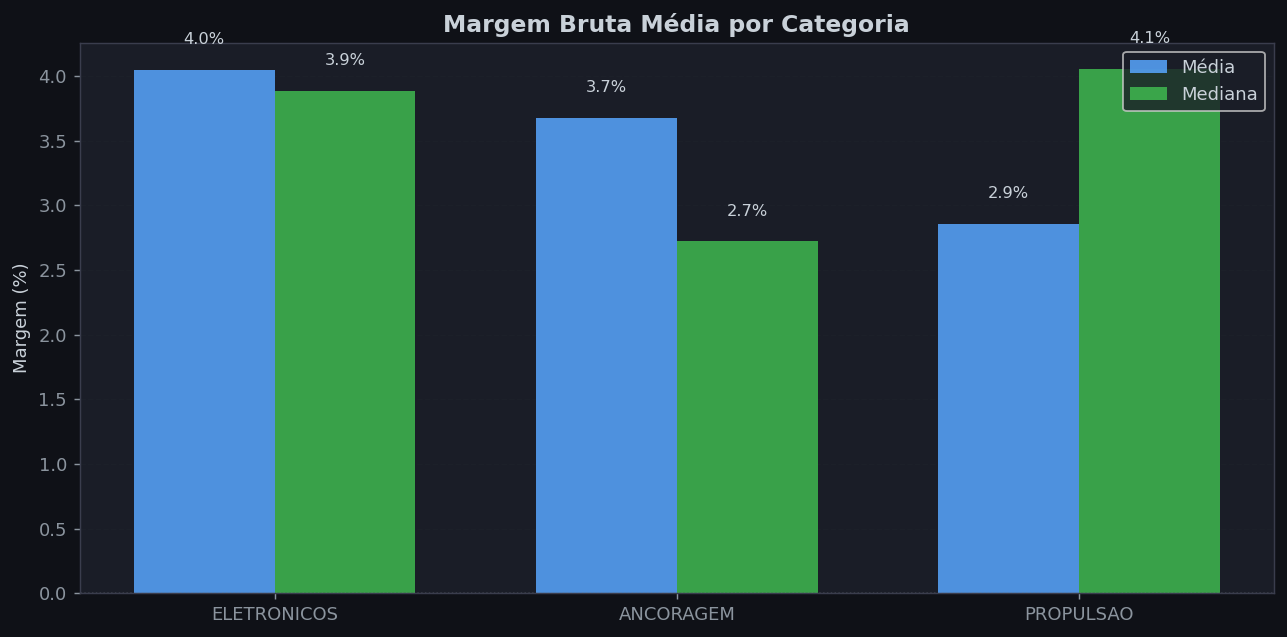

   category    media  mediana  negativos  n
ELETRONICOS 4.043222 3.882458         16 51
  ANCORAGEM 3.675290 2.720414         20 53
  PROPULSAO 2.856287 4.052363         13 53


In [12]:
mar_cat = (margem.groupby('category')
                 .agg(media=('margem_pct','mean'),
                      mediana=('margem_pct','median'),
                      negativos=('margem_pct', lambda x: (x<0).sum()),
                      n=('id_product','count'))
                 .reset_index().sort_values('media', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title('Margem Bruta Média por Categoria', fontsize=13, fontweight='bold')
x = np.arange(len(mar_cat)); w = 0.35
b1 = ax.bar(x-w/2, mar_cat['media'],   w, label='Média',   color=BLUE,  alpha=0.85)
b2 = ax.bar(x+w/2, mar_cat['mediana'], w, label='Mediana', color=GREEN, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(mar_cat['category'], fontsize=10)
ax.set_ylabel('Margem (%)'); ax.legend()
ax.axhline(0, color='#8b949e', lw=0.8, ls=':')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
            f'{b.get_height():.1f}%', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig8_margem_categoria.png', bbox_inches='tight', dpi=130)
plt.show()
print(mar_cat.to_string(index=False))


### 4.4 Mapa estratégico do portfólio — Receita × Margem

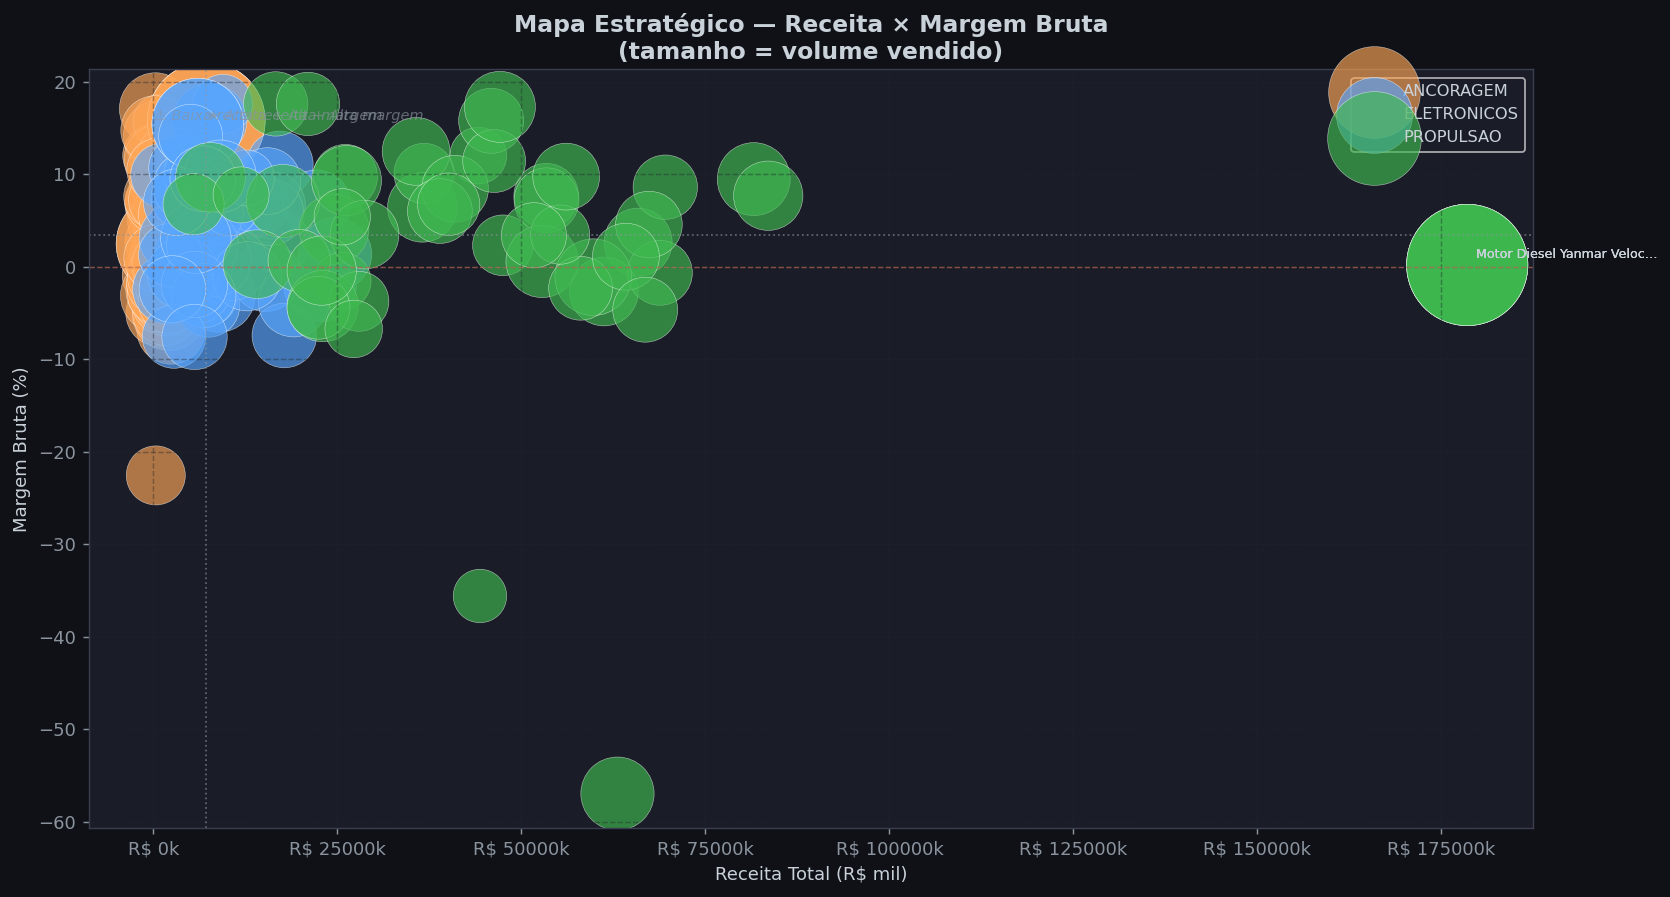

In [13]:
rev_prod = v.groupby('id_product').agg(receita=('total','sum'), qtd=('qtd','sum')).reset_index()
sc = margem.merge(rev_prod, on='id_product', how='inner').dropna(subset=['margem_pct','receita'])

med_rec = sc['receita'].median()
med_mar = sc['margem_pct'].median()

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_title('Mapa Estratégico — Receita × Margem Bruta\n(tamanho = volume vendido)',
             fontsize=13, fontweight='bold')

cat_col = {'ELETRONICOS': BLUE, 'PROPULSAO': GREEN, 'ANCORAGEM': ORANGE}
for cat, grp in sc.groupby('category'):
    ax.scatter(grp['receita']/1e3, grp['margem_pct'],
               s=grp['qtd']*2.5+30, alpha=0.65,
               color=cat_col.get(cat, RED), label=cat,
               edgecolors='white', linewidths=0.3)

ax.axvline(med_rec/1e3, color='#8b949e', ls=':', lw=1, alpha=0.6)
ax.axhline(med_mar,     color='#8b949e', ls=':', lw=1, alpha=0.6)
ax.axhline(0,           color=RED,       ls='--', lw=0.8, alpha=0.5)

kw = dict(fontsize=8, color='#8b949e', style='italic', alpha=0.65)
ax.text(med_rec/1e3*1.02, sc.margem_pct.max()*0.97, '★ Alta receita + Alta margem', va='top', **kw)
ax.text(sc.receita.min()/1e3, sc.margem_pct.max()*0.97, '⚠ Baixa receita + Alta margem', va='top', **kw)

ax.set_xlabel('Receita Total (R$ mil)')
ax.set_ylabel('Margem Bruta (%)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R$ {x:.0f}k'))
ax.legend(fontsize=9); ax.grid(alpha=0.4)

for _, row in sc.nlargest(3,'receita').iterrows():
    ax.annotate(shorten(row['name'], 25), xy=(row['receita']/1e3, row['margem_pct']),
                fontsize=7, color='#c9d1d9', xytext=(5,4), textcoords='offset points')

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig9_scatter_margem.png', bbox_inches='tight', dpi=130)
plt.show()


---
**Insight — Margens e Portfólio**

Com margem bruta na casa de **3–4%** em média, a operação é extremamente sensível ao câmbio — uma variação de 10% no USD/BRL corrói praticamente toda a margem de vários produtos. Produtos com **margem negativa** estão sendo vendidos abaixo do custo de importação: precisam de reajuste imediato ou devem ser descontinuados.

O **mapa estratégico** orienta a alocação de esforço comercial:
- **Alta receita + Alta margem** → defender e expandir
- **Alta receita + Baixa margem** → monitorar câmbio, preparar repasse
- **Baixa receita + Alta margem** → potencial inexplorado, investir em sell-out
- **Baixa receita + Baixa margem** → candidatos à descontinuação


---
## 5. Sumário Executivo

| Dimensão | Resultado | Ação |
|---|---|---|
| **Categoria líder** | Propulsão > 80% da receita | Gestão de estoque e câmbio prioritária |
| **Crescimento** | Receita +3,9% · Volume –1,5% | Reajuste de preços por câmbio em curso |
| **Churn** | 0% — base totalmente retida | Focar em cross-sell entre categorias |
| **Ticket médio** | ~R$ 265 mil (homogêneo) | Programa VIP para alto ticket + baixa freq. |
| **Margem** | ~3,5% média · negativos existem | Revisão trimestral atrelada ao USD/BRL |

> **Câmbio usado:** R$ 5,10/USD (média 2023–2024). Ajuste na variável `TAXA_CAMBIO` para simular cenários.
